# Юдин Артём М4121

In [ ]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    completeness_score,
    davies_bouldin_score,
    homogeneity_score,
    rand_score,
    silhouette_score,
    v_measure_score,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Предобработка

In [ ]:
X_train = pd.read_csv("../data/preprocessed/X_train_smart_regex_7020samples.csv")
X_val = pd.read_csv("../data/preprocessed/X_val_smart_regex_1980samples.csv")

y_train = pd.read_csv("../data/preprocessed/y_train_7020samples.csv")
y_val = pd.read_csv("../data/preprocessed/y_val_1980samples.csv")

# объединение токенов вместе
X_train["untokenized_ttext"] = X_train["ttext"].apply(lambda x: " ".join(eval(x)))
X_val["untokenized_ttext"] = X_val["ttext"].apply(lambda x: " ".join(eval(x)))
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

df = 5e-4
# инициализация векторизаторов
bow_vectorizer = CountVectorizer(min_df=df, max_df=1 - df)
tdidf_vectorizer = TfidfVectorizer(min_df=df, max_df=1 - df)

# инициализируем скейлеры
bow_scaler = StandardScaler()
tfidf_scaler = StandardScaler()

# кодируем и масштабируем данные
X_train_bow = bow_scaler.fit_transform(bow_vectorizer.fit_transform(X_train["untokenized_ttext"]).toarray())
X_val_bow = bow_scaler.transform(bow_vectorizer.transform(X_val["untokenized_ttext"]).toarray())

X_train_tfidf = tfidf_scaler.fit_transform(tdidf_vectorizer.fit_transform(X_train["untokenized_ttext"]).toarray())
X_val_tfidf = tfidf_scaler.transform(tdidf_vectorizer.transform(X_val["untokenized_ttext"]).toarray())

/home/artyom/myprojects/ITMO/IIML/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/artyom/myprojects/ITMO/IIML/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [ ]:
def train(X_train_bow, X_train_tfidf, y_train, X_val_bow, X_val_tfidf, y_val) -> dict[str, list]:
    # метрики, для которых нужен реальный класс
    outer_metrics = {
        "H": homogeneity_score,
        "R": rand_score,
        "V": v_measure_score,
        "C": completeness_score,
    }

    # метрики, для которых нужны векторы признаков
    inner_metrics = {
        "CH": calinski_harabasz_score,
        "S": silhouette_score,
        "DB": davies_bouldin_score,
    }

    models = {
        "KMeans++": KMeans(2, random_state=42),
        "DBSCAN": DBSCAN(eps=50, min_samples=3),
        "Agglomerative": AgglomerativeClustering(),
    }
    df_dict = {
        "Model": [],
        "Encoding": [],
        "CH": [],
        "S": [],
        "DB": [],
        "H": [],
        "R": [],
        "V": [],
        "C": [],
    }
    preds = {"KMeans++": [], "DBSCAN": [], "Agglomerative": []}
    remember = {"KMeans++": [], "DBSCAN": [], "Agglomerative": []}

    for model_name, model in models.items():
        df_dict["Model"].append(model_name)
        df_dict["Encoding"].append("BoW")

        # обучаем модель
        model.fit(X_train_bow, y_train)

        y_pred = model.predict(X_val_bow) if model_name == "KMeans++" else model.fit_predict(X_val_bow)

        remember[model_name].extend([y_pred[-2], y_pred[-1]])
        y_pred[-1] = 1
        y_pred[-2] = 0

        preds[model_name].append(y_pred)

        # рассчитываем метрики для обученного набора
        for metric_name, metric in outer_metrics.items():
            df_dict[metric_name].append(round(metric(y_val, y_pred), 2))

        for metric_name, metric in inner_metrics.items():
            df_dict[metric_name].append(round(metric(X_val_bow, y_pred), 2))

        df_dict["Model"].append(model_name)
        df_dict["Encoding"].append("TF-IDF")

        # обучаем модель
        model.fit(X_train_tfidf, y_train)

        y_pred = model.predict(X_val_tfidf) if model_name == "KMeans++" else model.fit_predict(X_val_tfidf)

        y_pred[-1] = 1
        y_pred[-2] = 0
        # рассчитываем метрики для обученного набора
        for metric_name, metric in outer_metrics.items():
            df_dict[metric_name].append(round(metric(y_val, y_pred), 2))

        for metric_name, metric in inner_metrics.items():
            df_dict[metric_name].append(round(metric(X_val_tfidf, y_pred), 2))

    return df_dict, preds, remember

In [ ]:
df_dict, preds, remember = train(X_train_bow, X_train_tfidf, y_train, X_val_bow, X_val_tfidf, y_val)
df = pd.DataFrame(df_dict)
df

,Model,Encoding,CH,S,DB,H,R,V,C
0,KMeans++,BoW,2.59,0.29,0.57,0.0,0.5,0.0,0.08
1,KMeans++,TF-IDF,2.29,0.16,3.38,0.0,0.5,0.0,0.00
2,DBSCAN,BoW,1.95,0.01,15.25,0.0,0.5,0.0,0.00
3,DBSCAN,TF-IDF,4.19,0.11,6.03,0.0,0.5,0.0,0.00
4,Agglomerative,BoW,7.42,0.34,1.60,0.0,0.5,0.0,0.10
5,Agglomerative,TF-IDF,7.49,0.12,1.92,0.0,0.5,0.0,0.03


In [134]:
for model_name, metrics in remember.items():
    preds[model_name][0][-2:] = metrics

In [ ]:
TSNE

In [145]:
def plot_tsne(X1, y1, y2, y3, y4, perplexity=10):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X1)

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    fig, ax = plt.subplots(2, 2, figsize=(12, 13))
    ax[0, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y1, cmap="Accent", alpha=0.7)
    ax[0, 0].grid(alpha=0.3)
    ax[0, 0].set_title("BoW")

    ax[1, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y2, alpha=0.7)
    ax[1, 0].grid(alpha=0.3)
    ax[1, 0].set_title("KMeans")

    ax[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y3, cmap="viridis", alpha=0.7)
    ax[0, 1].grid(alpha=0.3)
    ax[0, 1].set_title("DBSCAN")

    ax[1, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y4, cmap="plasma", alpha=0.7)
    ax[1, 1].grid(alpha=0.3)
    ax[1, 1].set_title("Agglomerative")


def plot_pca(X1, y1, y2, y3, y4, perplexity=10):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X1)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    fig, ax = plt.subplots(2, 2, figsize=(7, 8))
    ax[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y1, cmap="Accent", alpha=0.7)
    ax[0, 0].grid(alpha=0.3)
    ax[0, 0].set_title("BoW")

    ax[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y2, alpha=0.7)
    ax[1, 0].grid(alpha=0.3)
    ax[1, 0].set_title("KMeans")

    ax[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y3, cmap="viridis", alpha=0.7)
    ax[0, 1].grid(alpha=0.3)
    ax[0, 1].set_title("DBSCAN")

    ax[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y4, cmap="plasma", alpha=0.7)
    ax[1, 1].grid(alpha=0.3)
    ax[1, 1].set_title("Agglomerative")

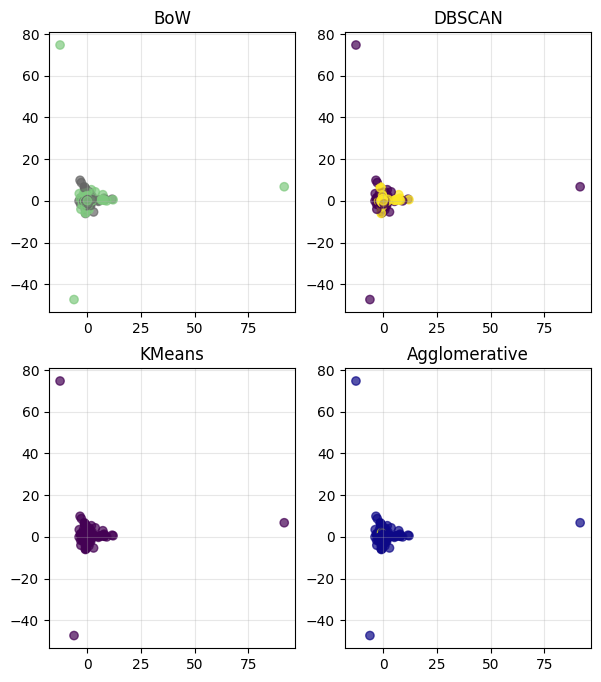

In [144]:
plot_pca(
    X_val_bow,
    y_val,
    preds["KMeans++"][0],
    preds["DBSCAN"][0],
    preds["Agglomerative"][0],
)

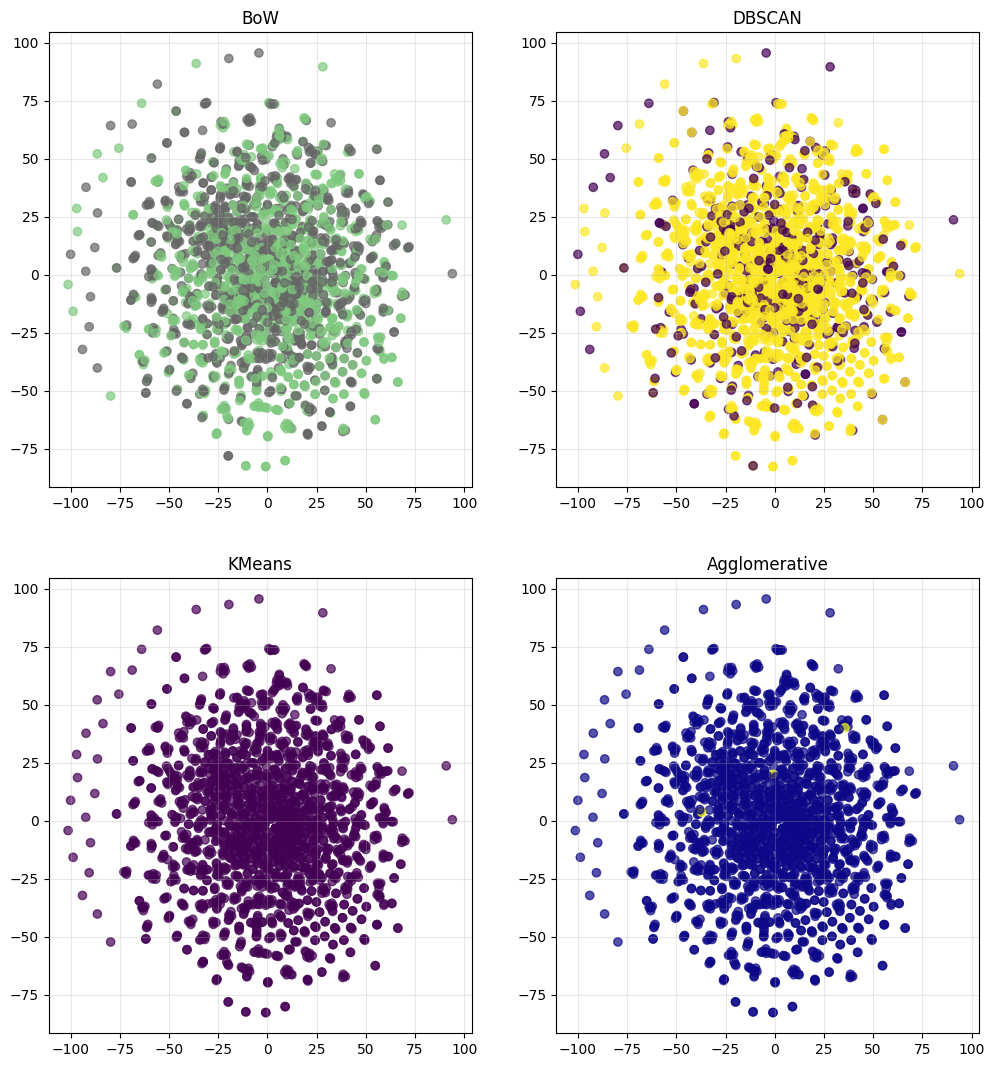

In [146]:
plot_tsne(
    X_val_bow,
    y_val,
    preds["KMeans++"][0],
    preds["DBSCAN"][0],
    preds["Agglomerative"][0],
)

In [136]:
for algo, classes in preds.items():
    classes = classes[0].tolist()
    print(algo, Counter(classes))

KMeans++ Counter({1: 1980})
DBSCAN Counter({0: 1631, -1: 349})
Agglomerative Counter({0: 1977, 1: 3})


# Выводы
- Все модели показали разбиение по классам на уровне случайного (индекс Рэнда равен 0.5)
- Аггломеративная кластеризация показала лучше группировку по классам, но вместе с тем немного хуже разделяемость самих кластеров
- К-средних отработал хуже аггломеративной кластеризации, что говорит о том, что попарная кластеризация даёт на наших данных результат лучше, чем групповая